Name: Ahmed Sherif

ID: EYOUTH-31012042601655

Project name: online learning engagement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

-------
## Importing Data
-------

In [2]:
df = pd.read_csv("./online_learning_engagement_dataset.csv")
df.sample(5)

,learner_id,gender,age,education_level,course_type,learning_mode,region,device_type,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score,participation_level,completion_status,performance_category
4421,LRN04422,Male,30.0,Undergraduate,Design,Self-paced,Cairo,Laptop,6.6,15 videos,6,54.2,56.6,51.8,46.405386,Medium,Not Completed,Needs Support
3290,LRN03291,Female,21.0,Undergraduate,Data Analysis,Self-paced,Alexandria,Tablet,4.6,18 videos,3,50.8,79.6,42.6,49.792086,Medium,Not Completed,Needs Support
2245,LRN02246,Female,34.0,Graduate,Data Analysis,Instructor-led,Cairo,Tablet,8.1,28 videos,1,72.2,69.6,79.1,69.813545,High,Completed,Very Good
3918,LRN03919,Male,35.0,Professional,Business,Instructor-led,Giza,Laptop,9.3,24 videos,6,97.9,92.0,97.7,84.143410,High,Completed,Excellent
3761,LRN03762,Female,33.0,Professional,AI Fundamentals,Self-paced,Delta,Laptop,9.9,29 videos,2,98.0,89.7,79.7,79.199939,High,Completed,Very Good


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   learner_id                   5010 non-null   object 
 1   gender                       5010 non-null   object 
 2   age                          5000 non-null   float64
 3   education_level              5010 non-null   object 
 4   course_type                  5010 non-null   object 
 5   learning_mode                5010 non-null   object 
 6   region                       5010 non-null   object 
 7   device_type                  4998 non-null   object 
 8   study_hours_per_week         5005 non-null   float64
 9   videos_watched               5010 non-null   object 
 10  forum_posts                  5010 non-null   int64  
 11  assignments_completed_score  5010 non-null   float64
 12  quiz_score                   5010 non-null   float64
 13  engagement_score  

In [4]:
df.describe()

,age,study_hours_per_week,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score
count,5000.000000,5005.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,27.098800,6.802018,3.661677,69.861078,76.690060,67.642475,63.337923
std,6.694894,3.090270,2.170306,16.476049,14.299289,19.619488,14.820706
min,16.000000,1.000000,0.000000,16.900000,27.700000,1.800000,10.967643
25%,22.000000,4.600000,2.000000,58.300000,66.500000,54.200000,53.003388
50%,27.000000,6.800000,3.000000,70.400000,77.450000,69.100000,64.082434
75%,32.000000,8.900000,5.000000,81.900000,87.400000,82.100000,74.036726
max,53.000000,18.500000,15.000000,100.000000,100.000000,100.000000,100.000000


----
## Cleaning Data
----

In [5]:
df.isnull().sum()

learner_id                      0
gender                          0
age                            10
education_level                 0
course_type                     0
learning_mode                   0
region                          0
device_type                    12
study_hours_per_week            5
videos_watched                  0
forum_posts                     0
assignments_completed_score     0
quiz_score                      0
engagement_score                0
final_score                     0
participation_level             0
completion_status               0
performance_category            0
dtype: int64

In [6]:
df_cleaned = df.copy()

for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        mode_value = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)
    elif df_cleaned[col].dtype in ['int64', 'float64']:
        mean_value = df_cleaned[col].mean()
        df_cleaned[col] = df_cleaned[col].fillna(mean_value)


In [7]:
df_cleaned["completion_status_binary"] = df_cleaned["completion_status"].apply(lambda x: 1 if x == "Completed" else 0)

In [8]:
df_cleaned.head()

,learner_id,gender,age,education_level,course_type,learning_mode,region,device_type,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score,participation_level,completion_status,performance_category,completion_status_binary
0,LRN00001,Male,30.0,Undergraduate,Business,Blended,Upper Egypt,Mobile,7.2,26 videos,4,73.4,75.1,69.1,64.706031,High,Completed,Good,1
1,LRN00002,Male,34.0,Graduate,Business,Self-paced,Delta,Laptop,9.3,22 videos,5,69.8,85.8,76.3,69.859459,High,Completed,Very Good,1
2,LRN00003,Female,22.0,Graduate,Business,Blended,Cairo,Mobile,8.6,27 videos,2,90.1,88.1,77.0,80.398954,High,Completed,Excellent,1
3,LRN00004,Female,23.0,Undergraduate,Design,Self-paced,Delta,Tablet,6.8,22 videos,3,46.3,69.9,52.3,59.604156,Medium,Not Completed,Good,0
4,LRN00005,Female,21.0,Undergraduate,Business,Self-paced,Cairo,Mobile,1.0,11 videos,3,17.2,42.3,15.0,26.339235,Low,Not Completed,Needs Support,0


In [9]:
df_cleaned.to_csv('online_learning_engagement_cleaned.csv', index=False)
print("done")

done


----------------
## Probability & Distribution Step
----------------

In [10]:
prob_completion = df_cleaned['completion_status_binary'].mean()
print(f"Probability of Completion: {prob_completion:.3%}")

Probability of Completion: 59.661%


In [11]:
students_needs_support = df_cleaned[df_cleaned['performance_category'] == 'Needs Support']
students_needs_support_percentage = (len(students_needs_support) / len(df_cleaned)) * 100
print(f"Percentage of Students Who Need Support: {students_needs_support_percentage:.2f}%")

Percentage of Students Who Need Support: 18.92%


Text(0.5, 1.0, 'final grades distribution')

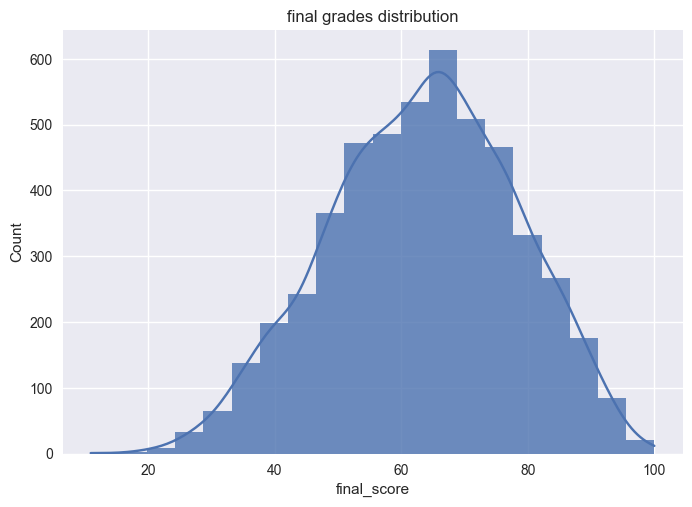

In [12]:
sns.histplot(df_cleaned["final_score"], kde=True, bins=20, edgecolor=None, alpha=0.8)
plt.title("final grades distribution")

-----
## Visual Evidence
-----

In [13]:
df_cleaned.head()

,learner_id,gender,age,education_level,course_type,learning_mode,region,device_type,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score,participation_level,completion_status,performance_category,completion_status_binary
0,LRN00001,Male,30.0,Undergraduate,Business,Blended,Upper Egypt,Mobile,7.2,26 videos,4,73.4,75.1,69.1,64.706031,High,Completed,Good,1
1,LRN00002,Male,34.0,Graduate,Business,Self-paced,Delta,Laptop,9.3,22 videos,5,69.8,85.8,76.3,69.859459,High,Completed,Very Good,1
2,LRN00003,Female,22.0,Graduate,Business,Blended,Cairo,Mobile,8.6,27 videos,2,90.1,88.1,77.0,80.398954,High,Completed,Excellent,1
3,LRN00004,Female,23.0,Undergraduate,Design,Self-paced,Delta,Tablet,6.8,22 videos,3,46.3,69.9,52.3,59.604156,Medium,Not Completed,Good,0
4,LRN00005,Female,21.0,Undergraduate,Business,Self-paced,Cairo,Mobile,1.0,11 videos,3,17.2,42.3,15.0,26.339235,Low,Not Completed,Needs Support,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'study_hours_per_week'}>,
        <Axes: title={'center': 'forum_posts'}>],
       [<Axes: title={'center': 'assignments_completed_score'}>,
        <Axes: title={'center': 'quiz_score'}>,
        <Axes: title={'center': 'engagement_score'}>],
       [<Axes: title={'center': 'final_score'}>,
        <Axes: title={'center': 'completion_status_binary'}>, <Axes: >]],
      dtype=object)

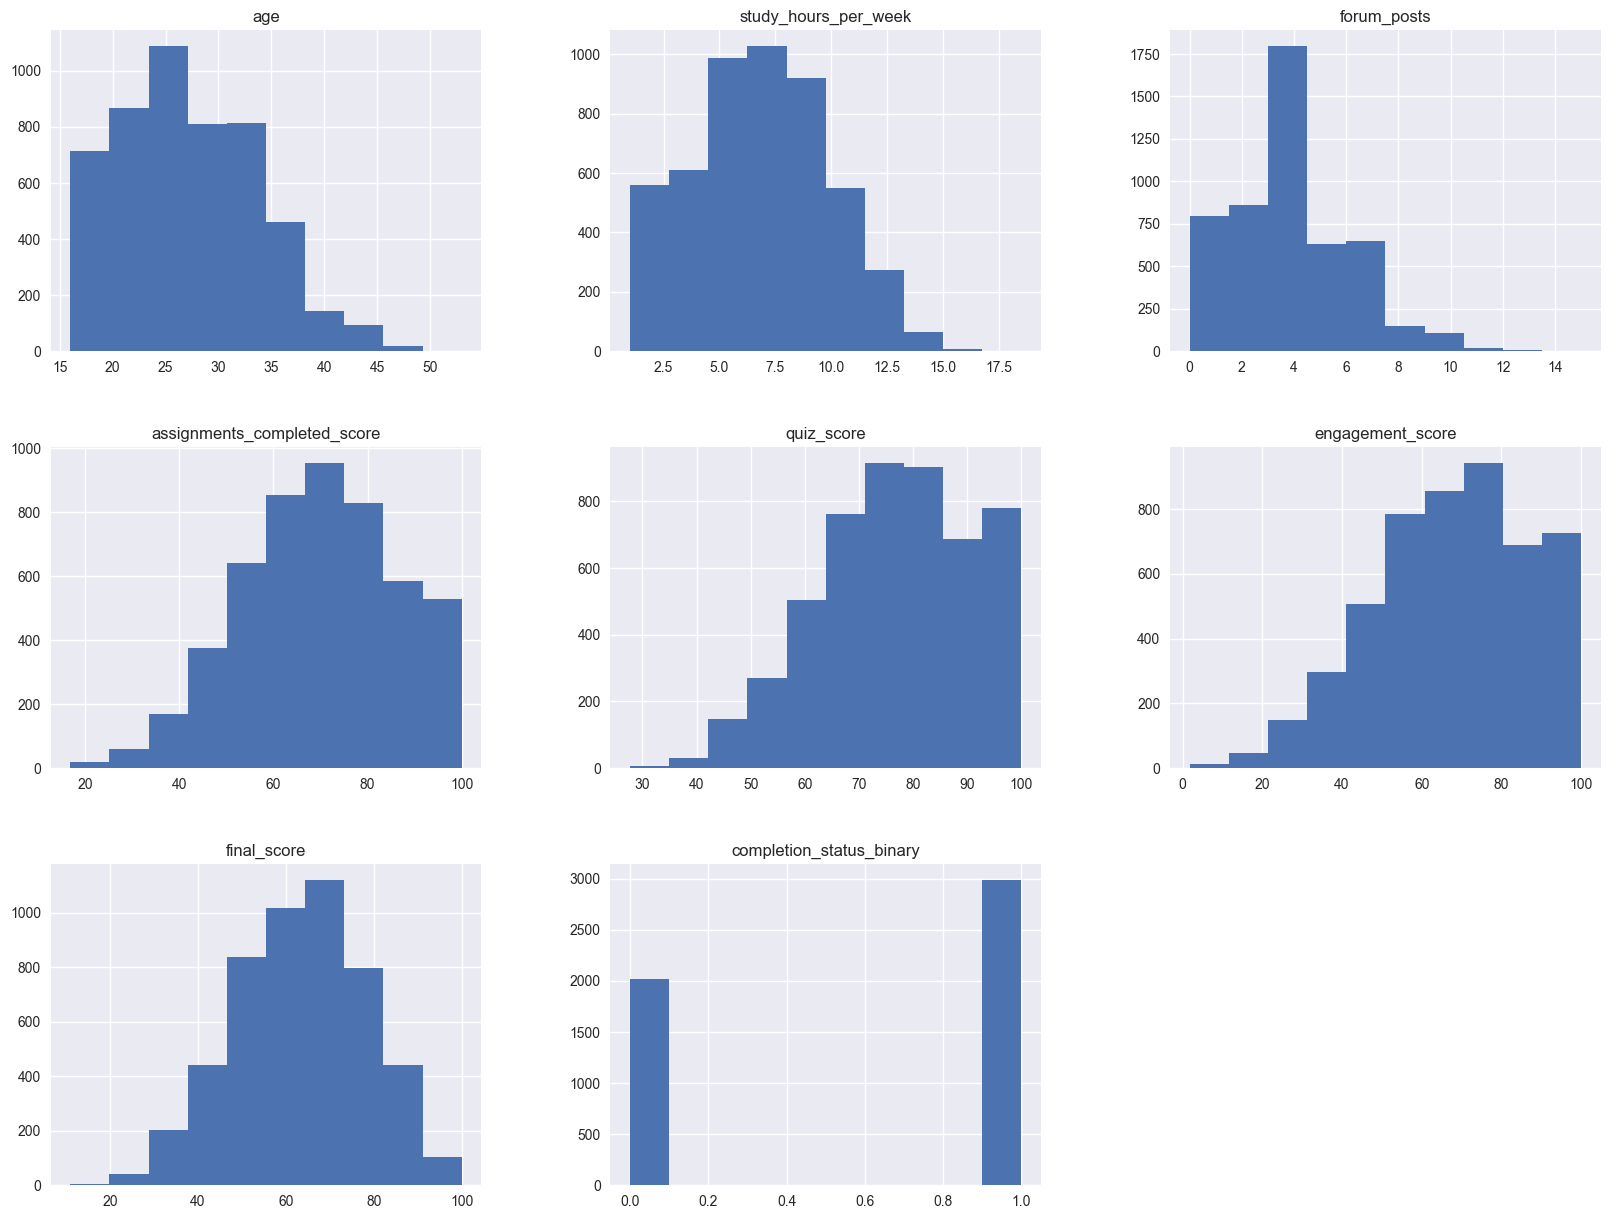

In [14]:
df_cleaned.hist(figsize=(20,15))

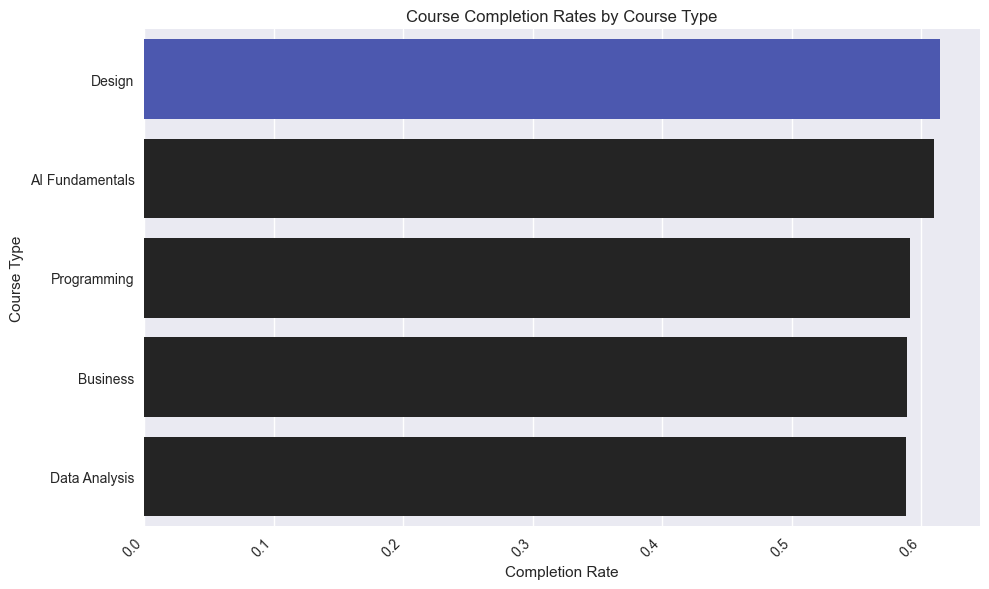

In [15]:
completion_rates_by_course = df_cleaned.groupby('course_type')['completion_status_binary'].mean().sort_values(ascending=False)
palette = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_course))]
plt.figure(figsize=(10, 6))
sns.barplot(x=completion_rates_by_course.values, y=completion_rates_by_course.index ,hue=completion_rates_by_course.index, palette=palette)
plt.title('Course Completion Rates by Course Type')
plt.ylabel('Course Type')
plt.xlabel('Completion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Final Score Distribution by participation_level')

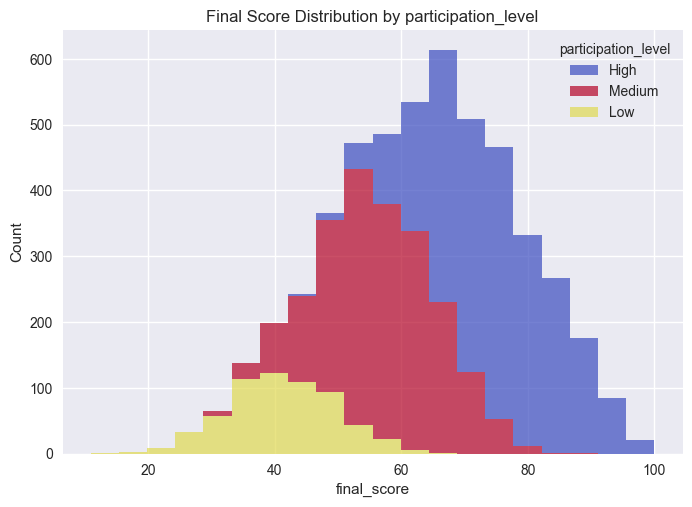

In [16]:
sns.histplot(data=df_cleaned, x="final_score", bins=20, edgecolor=None, alpha=0.7, hue="participation_level", palette=["#3B4CC0", "#B40426", "#e0d951"], multiple="stack")
plt.title("Final Score Distribution by participation_level")

Text(0.5, 1.0, 'engagement Score Distribution by learning mode')

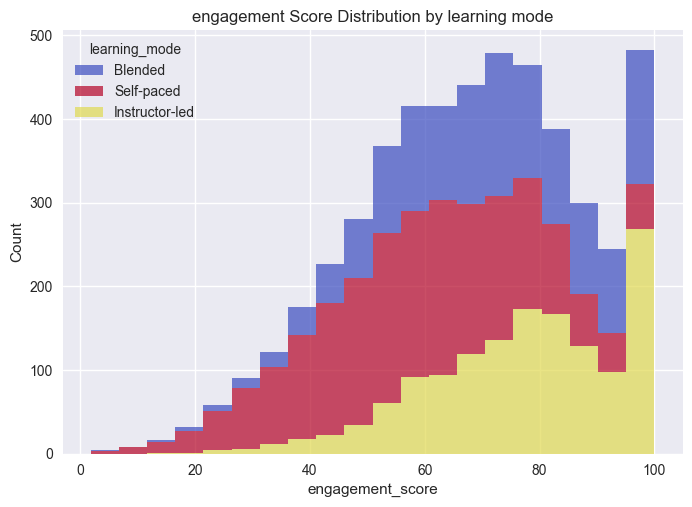

In [17]:
sns.histplot(data=df_cleaned, x="engagement_score", bins=20, edgecolor=None, alpha=0.7, hue="learning_mode", palette=["#3B4CC0","#B40426", "#e0d951"], multiple="stack")
plt.title("engagement Score Distribution by learning mode")

Text(0.5, 1.0, 'study hours weekly corrilation to engagement score')

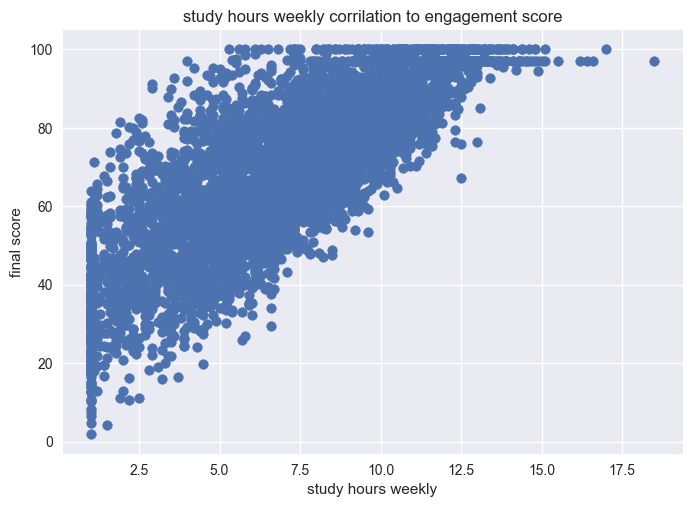

In [18]:
plt.scatter(df_cleaned["study_hours_per_week"], df_cleaned["engagement_score"])
plt.xlabel("study hours weekly")
plt.ylabel("final score")
plt.title("study hours weekly corrilation to engagement score")

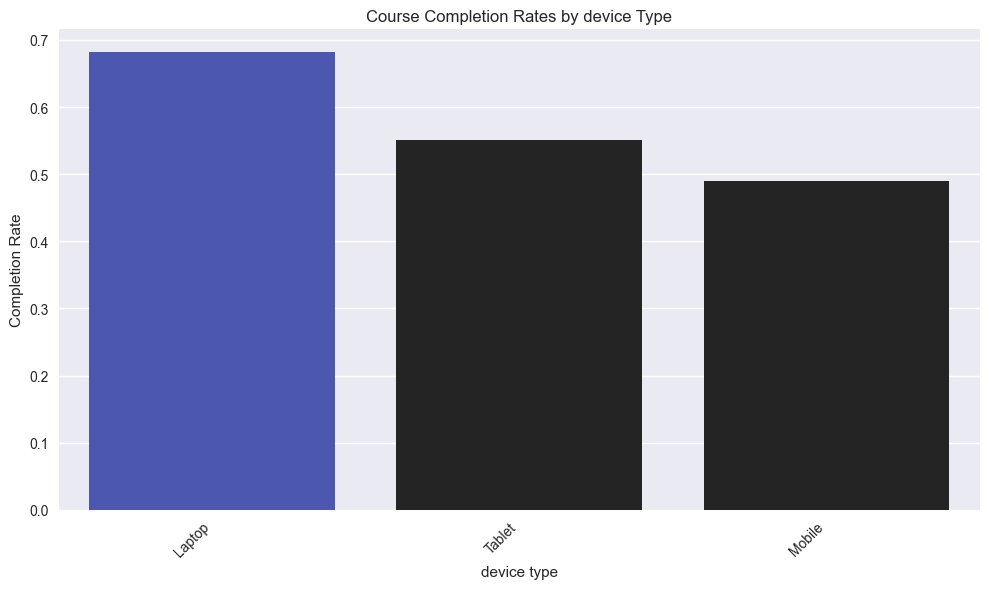

In [19]:
completion_rates_by_device_type= df_cleaned.groupby('device_type')['completion_status_binary'].mean().sort_values(ascending=False)
palette = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_device_type))]
plt.figure(figsize=(10, 6))
sns.barplot(x=completion_rates_by_device_type.index, y=completion_rates_by_device_type.values ,hue=completion_rates_by_device_type.index, palette=palette)
plt.title('Course Completion Rates by device Type')
plt.ylabel('Completion Rate')
plt.xlabel('device type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

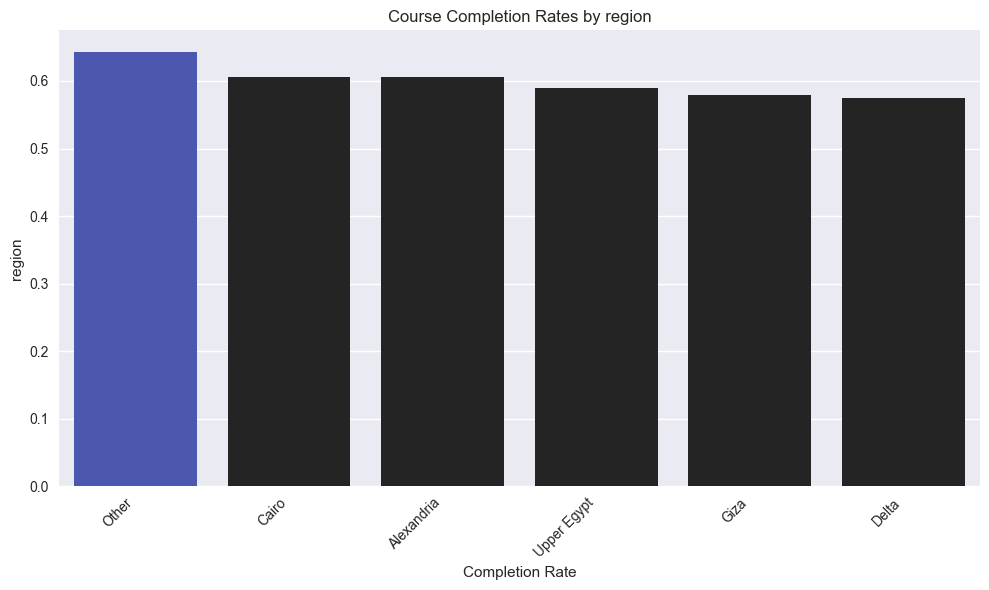

In [20]:
completion_rates_by_region= df_cleaned.groupby('region')['completion_status_binary'].mean().sort_values(ascending=False)
palette = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_region))]
plt.figure(figsize=(10, 6))
sns.barplot(x=completion_rates_by_region.index, y=completion_rates_by_region.values ,hue=completion_rates_by_region.index, palette=palette)
plt.title('Course Completion Rates by region')
plt.ylabel('region')
plt.xlabel('Completion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

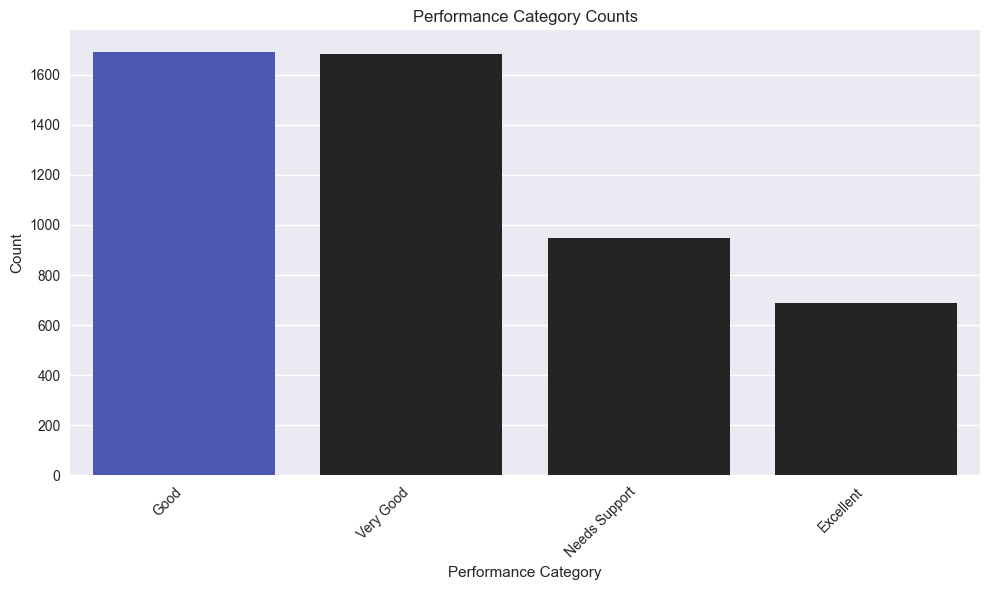

In [21]:
performance_category_count = df_cleaned['performance_category'].value_counts().reset_index()
performance_category_count.columns = ['performance_category', 'count']

palette = ["#3B4CC0" if category == 'Good' else "#242424" for category in performance_category_count['performance_category']]

plt.figure(figsize=(10, 6))
sns.barplot(data=performance_category_count, x='performance_category', y='count', hue='performance_category', palette=palette, legend=False)
plt.title('Performance Category Counts')
plt.ylabel('Count')
plt.xlabel('Performance Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

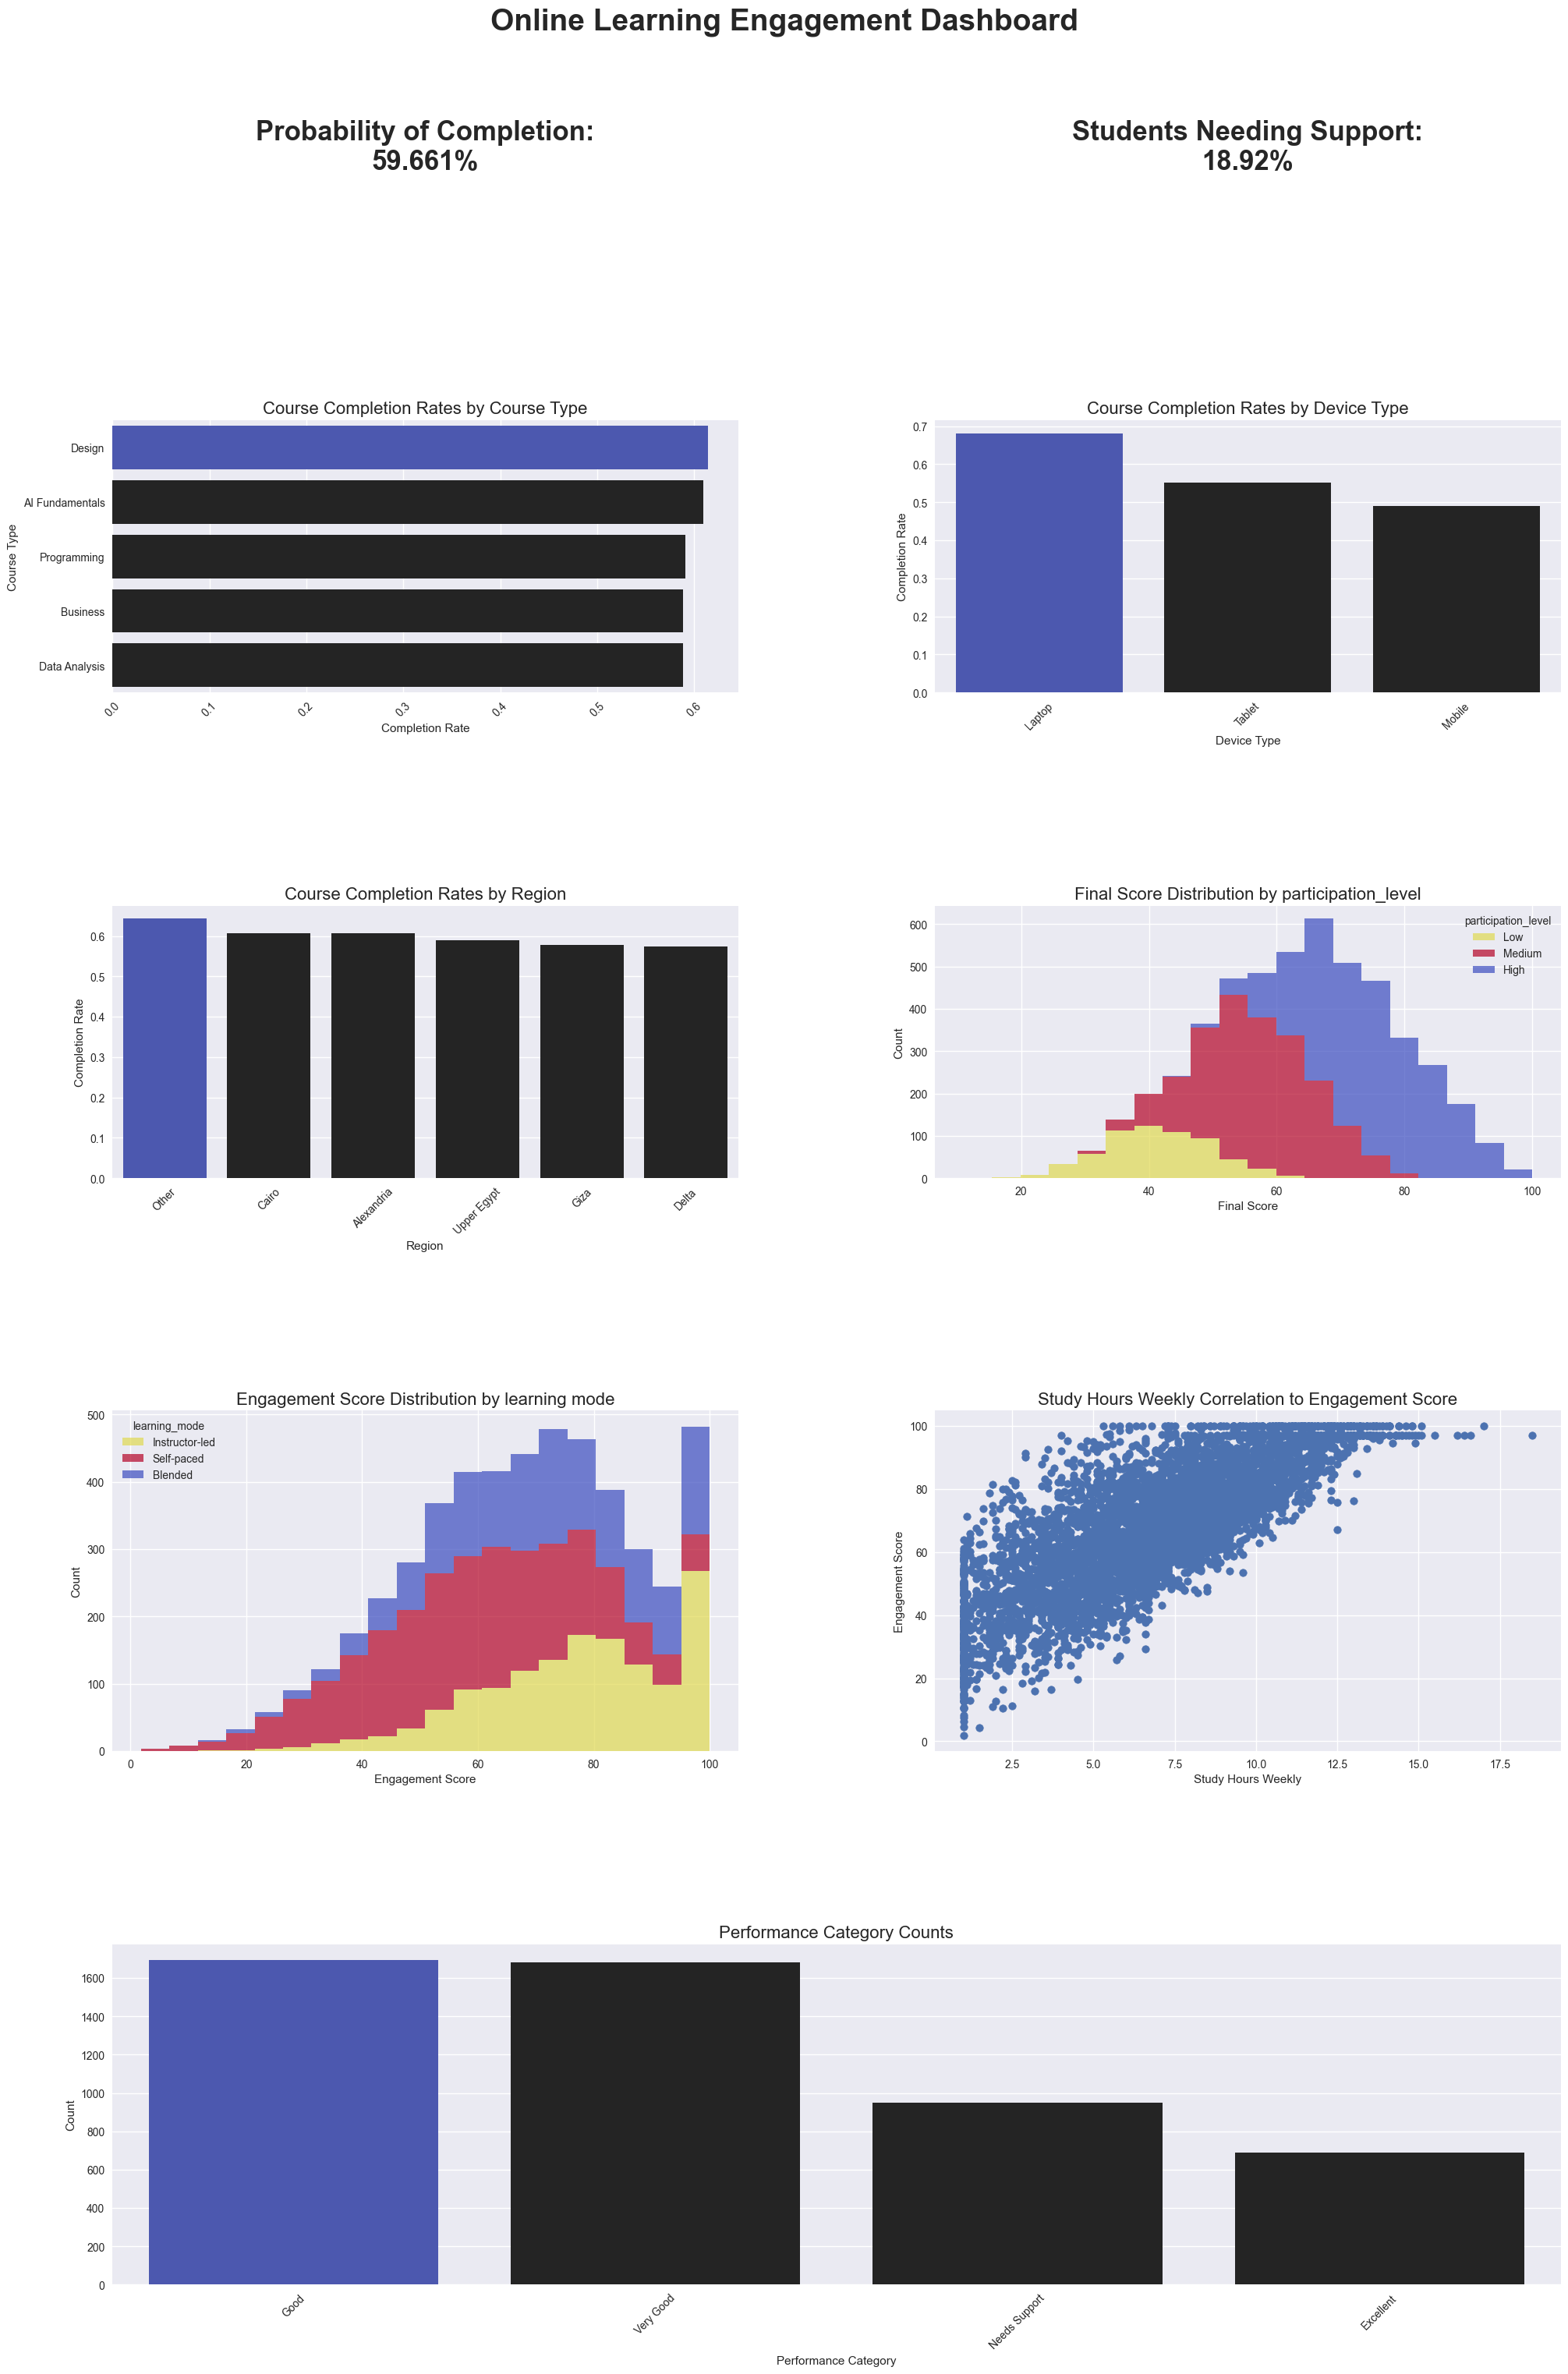

In [23]:
import matplotlib.gridspec as gridspec


fig = plt.figure(figsize=(20, 30), constrained_layout=True)
fig.suptitle('Online Learning Engagement Dashboard', fontsize=28, weight='bold', y=1.01)


gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.3, wspace=0.1, height_ratios=[1, 1.2, 1.2, 1.5, 1.5])


ax0 = fig.add_subplot(gs[0, 0])
ax0.text(0.5, 0.5, f'Probability of Completion:\n{prob_completion:.3%}',
         ha='center', va='center', fontsize=25, weight='bold')
ax0.axis('off')


ax1 = fig.add_subplot(gs[0, 1])
ax1.text(0.5, 0.5, f'Students Needing Support:\n{students_needs_support_percentage:.2f}%',
         ha='center', va='center', fontsize=25, weight='bold')
ax1.axis('off')


ax2 = fig.add_subplot(gs[1, 0])
completion_rates_by_course = df_cleaned.groupby('course_type')['completion_status_binary'].mean().sort_values(ascending=False)
palette_course = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_course))]
sns.barplot(x=completion_rates_by_course.values, y=completion_rates_by_course.index ,hue=completion_rates_by_course.index, palette=palette_course, ax=ax2, legend=False)
ax2.set_title('Course Completion Rates by Course Type', fontsize=16)
ax2.set_ylabel('Course Type')
ax2.set_xlabel('Completion Rate')
ax2.tick_params(axis='x', rotation=45)


ax3 = fig.add_subplot(gs[1, 1])
completion_rates_by_device_type= df_cleaned.groupby('device_type')['completion_status_binary'].mean().sort_values(ascending=False)
palette_device = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_device_type))]
sns.barplot(x=completion_rates_by_device_type.index, y=completion_rates_by_device_type.values ,hue=completion_rates_by_device_type.index, palette=palette_device, ax=ax3, legend=False)
ax3.set_title('Course Completion Rates by Device Type', fontsize=16)
ax3.set_ylabel('Completion Rate')
ax3.set_xlabel('Device Type')
ax3.tick_params(axis='x', rotation=45)


ax4 = fig.add_subplot(gs[2, 0])
completion_rates_by_region= df_cleaned.groupby('region')['completion_status_binary'].mean().sort_values(ascending=False)
palette_region = ["#3B4CC0" if index == 0 else "#242424" for index in range(0, len(completion_rates_by_region))]
sns.barplot(x=completion_rates_by_region.index, y=completion_rates_by_region.values ,hue=completion_rates_by_region.index, palette=palette_region, ax=ax4, legend=False)
ax4.set_title('Course Completion Rates by Region', fontsize=16)
ax4.set_ylabel('Completion Rate')
ax4.set_xlabel('Region')
ax4.tick_params(axis='x', rotation=45)


ax5 = fig.add_subplot(gs[2, 1])
sns.histplot(data=df_cleaned, x="final_score", bins=20, edgecolor=None, alpha=0.7, hue="participation_level", palette=["#3B4CC0", "#B40426", "#e0d951"], multiple="stack", ax=ax5, legend=False)
ax5.set_title("Final Score Distribution by participation_level", fontsize=16)
ax5.set_xlabel('Final Score')
ax5.set_ylabel('Count')
ax5.legend(title='participation_level', labels=['Low', 'Medium', 'High'])

ax6 = fig.add_subplot(gs[3, 0])
sns.histplot(data=df_cleaned, x="engagement_score", bins=20, edgecolor=None, alpha=0.7, hue="learning_mode", palette=["#3B4CC0","#B40426", "#e0d951"], multiple="stack", ax=ax6, legend=False)
ax6.set_title("Engagement Score Distribution by learning mode", fontsize=16)
ax6.set_xlabel('Engagement Score')
ax6.set_ylabel('Count')
ax6.legend(title='learning_mode', labels=['Instructor-led', 'Self-paced', 'Blended'])


ax7 = fig.add_subplot(gs[3, 1])
ax7.scatter(df_cleaned["study_hours_per_week"], df_cleaned["engagement_score"])
ax7.set_xlabel("Study Hours Weekly")
ax7.set_ylabel("Engagement Score")
ax7.set_title("Study Hours Weekly Correlation to Engagement Score", fontsize=16)


ax8 = fig.add_subplot(gs[4, :])
performance_category_count = df_cleaned['performance_category'].value_counts().reset_index()
performance_category_count.columns = ['performance_category', 'count']
palette_perf_cat = ["#3B4CC0" if category == 'Good' else "#242424" for category in performance_category_count['performance_category']]
sns.barplot(data=performance_category_count, x='performance_category', y='count', hue='performance_category', palette=palette_perf_cat, legend=False, ax=ax8)
ax8.set_title('Performance Category Counts', fontsize=16)
ax8.set_ylabel('Count')
ax8.set_xlabel('Performance Category')
ax8.tick_params(axis='x', rotation=45)

plt.savefig('EYOUTH-31012042601655_online_learning_engagement.png', dpi=100, bbox_inches='tight')
plt.show()